In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import sys

data_dir = Path("../data/csv")
sys.path.append("../src")

from plot_style import set_project_style, COLOR_DARK, COLOR_ACCENT, COLOR_BG
set_project_style()

In [2]:
# Initial exploration: structure of the files generated by Synthea
# Load just a preview of the files rows and columns

files = ["patients.csv", "conditions.csv", "observations.csv",
         "medications.csv", "encounters.csv"]

for f in files:
    path = data_dir / f
    preview = pd.read_csv(path, nrows=5)
    print(f"--- {f} ---")
    print("Colonne:", list(preview.columns))
    print(preview.head(2))
    print()

--- patients.csv ---
Colonne: ['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'INCOME']
                                     Id   BIRTHDATE  DEATHDATE          SSN  \
0  7c9e3c55-f225-5b68-ee2f-dab71e12772c  2023-01-14        NaN  999-39-2522   
1  720fe4ff-be67-e0d7-ff15-d5fee26722a6  1999-10-06        NaN  999-28-5295   

     DRIVERS    PASSPORT PREFIX      FIRST      MIDDLE        LAST  ...  \
0        NaN         NaN    NaN  Rafael239  Ricardo560  Hurtado459  ...   
1  S99918885  X15139376X    Ms.  Paulita78   Ileana390   Torphy630  ...   

           CITY          STATE            COUNTY     FIPS   ZIP        LAT  \
0        Revere  Massachusetts    Suffolk County  25025.0  2151  42.444413   
1  Southborough  Massachusetts  Worcester County   

In [3]:
# [Step 1]: identify the Type 2 Diabetes cohort from conditions.csv

# Load just the 3 columns needed to reduces memory usage
conditions = pd.read_csv(
    data_dir / "conditions.csv",
    usecols=["PATIENT", "CODE", "DESCRIPTION"]
)

# SNOMED-CT code for Type 2 Diabetes Mellitus (see protocol, Section 1)
T2D_CODE = 44054006

t2d_patients = conditions.loc[conditions["CODE"] == T2D_CODE, "PATIENT"].unique()

print(f"Patients with a Type 2 Diabetes diagnosis: {len(t2d_patients)}")

Patients with a Type 2 Diabetes diagnosis: 1763


In [4]:
# [Step 2]: extract relevant lab observations for the T2D cohort
# observations.csv is too large (~3 GB) to load entirely -> read in chunks
# and filter on both PATIENT and CODE while reading

t2d_patients_set = set(t2d_patients)  # set lookup is much faster than list

# LOINC codes for the variables defined in the protocol (Section 2)
relevant_codes = {
    "4548-4":  "HbA1c",
    "2339-0":  "Glucose",
    "39156-5": "BMI",
    "2089-1":  "LDL",
    "2085-9":  "HDL",
    "2571-8":  "Triglycerides",
    "2160-0":  "Creatinine",
}

chunks = []
chunk_size = 500_000  # rows per chunk

reader = pd.read_csv(
    data_dir / "observations.csv",
    usecols=["PATIENT", "CODE", "DATE", "VALUE", "UNITS"],
    chunksize=chunk_size
)

for chunk in reader:
    mask = (
        chunk["PATIENT"].isin(t2d_patients_set)
        & chunk["CODE"].isin(relevant_codes.keys())
    )
    if mask.any():
        chunks.append(chunk.loc[mask])

observations_t2d = pd.concat(chunks, ignore_index=True)
print(f"Filtered rows: {len(observations_t2d)}")
print(observations_t2d["CODE"].value_counts())

Filtered rows: 347292
CODE
4548-4     69899
2339-0     64831
2571-8     55735
2085-9     55735
39156-5    51605
2160-0     49487
Name: count, dtype: int64


In [5]:
# LDL (LOINC 2089-1) returned 0 rows -> investigate which cholesterol-related
# codes actually exist for our cohort, by searching the DESCRIPTION field

found_codes = set()

reader = pd.read_csv(
    data_dir / "observations.csv",
    usecols=["PATIENT", "CODE", "DESCRIPTION"],
    chunksize=500_000
)

for chunk in reader:
    mask = (
        chunk["PATIENT"].isin(t2d_patients_set)
        & chunk["DESCRIPTION"].str.contains("cholesterol|LDL", case=False, na=False, regex=True)
    )
    if mask.any():
        pairs = chunk.loc[mask, ["CODE", "DESCRIPTION"]].drop_duplicates()
        found_codes.update(pairs.itertuples(index=False, name=None))

for code, desc in sorted(found_codes):
    print(code, "-", desc)

18262-6 - Cholesterol in LDL [Mass/volume] in Serum or Plasma by Direct assay
2085-9 - Cholesterol in HDL [Mass/volume] in Serum or Plasma
2093-3 - Cholesterol [Mass/volume] in Serum or Plasma


In [6]:
# Updated mapping based on actual codes found in the dataset
# (deviation from protocol: 2089-1 not present -> replaced with 18262-6;
# 2093-3 added as it was found and is clinically informative)
relevant_codes = {
    "4548-4":  "HbA1c",
    "2339-0":  "Glucose",
    "39156-5": "BMI",
    "18262-6": "LDL",
    "2085-9":  "HDL",
    "2093-3":  "Total Cholesterol",
    "2571-8":  "Triglycerides",
    "2160-0":  "Creatinine",
}

# [Step 2]: extract relevant lab observations for the T2D cohort
# observations.csv is too large (~3 GB) to load entirely -> read in chunks
# and filter on both PATIENT and CODE while reading

t2d_patients_set = set(t2d_patients)  # set lookup is much faster than list

chunks = []
chunk_size = 500_000  # rows per chunk

reader = pd.read_csv(
    data_dir / "observations.csv",
    usecols=["PATIENT", "CODE", "DATE", "VALUE", "UNITS"],
    chunksize=chunk_size
)

for chunk in reader:
    mask = (
        chunk["PATIENT"].isin(t2d_patients_set)
        & chunk["CODE"].isin(relevant_codes.keys())
    )
    if mask.any():
        chunks.append(chunk.loc[mask])

observations_t2d = pd.concat(chunks, ignore_index=True)
print(f"Filtered rows: {len(observations_t2d)}")
print(observations_t2d["CODE"].value_counts())

Filtered rows: 458762
CODE
4548-4     69899
2339-0     64831
2093-3     55735
2571-8     55735
18262-6    55735
2085-9     55735
39156-5    51605
2160-0     49487
Name: count, dtype: int64


**Deviation note**: the originally planned LOINC code for LDL cholesterol (`2089-1`,
"LDL calculated") returned zero observations for this cohort. Investigation by
`DESCRIPTION` search identified `18262-6` ("Cholesterol in LDL, direct assay") as the
code actually used by Synthea. The lab variable mapping was updated accordingly, and
total cholesterol (`2093-3`) was added as an additional variable found during the same
search. See `docs/protocol.md` for full details.

In [7]:
# [Step 3]: reshape from long format (one row per observation) to wide format
# (one row per patient, one column per lab variable), keeping the latest
# available value per patient/variable

# Note: VALUE is read as object dtype by pandas, because observations.csv
# mixes numeric and text observation types (dtype is inferred per chunk).
# Convert to numeric before pivoting -> our 8 lab codes are all numeric.
observations_t2d["VALUE"] = pd.to_numeric(observations_t2d["VALUE"], errors="coerce")

observations_t2d["DATE"] = pd.to_datetime(observations_t2d["DATE"])

# sort by date, then keep the last (most recent) row for each patient/code pair
latest_obs = (
    observations_t2d
    .sort_values("DATE")
    .groupby(["PATIENT", "CODE"], as_index=False)
    .last()
)

# replace LOINC codes with readable variable names
latest_obs["VARIABLE"] = latest_obs["CODE"].map(relevant_codes)

# pivot: one row per patient, one column per variable
patient_labs = latest_obs.pivot(index="PATIENT", columns="VARIABLE", values="VALUE")

print(f'Df shape: {patient_labs.shape}')
print('\nDf NA values % by variable:')
print(patient_labs.isna().mean().round(3) * 100)  # share of missing values per column
patient_labs.head()

Df shape: (1763, 8)

Df NA values % by variable:
VARIABLE
BMI                   0.0
Creatinine           52.4
Glucose               0.0
HDL                   0.0
HbA1c                 0.0
LDL                   0.0
Total Cholesterol     0.0
Triglycerides         0.0
dtype: float64


VARIABLE,BMI,Creatinine,Glucose,HDL,HbA1c,LDL,Total Cholesterol,Triglycerides
PATIENT,,,,,,,,
0003c6da-971f-a2b1-8693-4c1a27f98985,27.6,2.0,110.2,48.8,3.9,124.3,205.6,162.7
0005fc0b-a254-8215-d848-1a20685b750f,27.9,2.0,97.1,60.7,5.5,104.8,187.8,111.8
0012304f-0715-b5e9-efa2-ee32e57cfb57,30.7,NaN,99.6,53.2,6.2,125.5,200.3,108.1
00681a7d-5dad-ecfe-af77-b65f8da3fa15,28.3,NaN,70.0,52.0,5.6,112.8,178.0,181.2
007603dc-125f-14a7-4318-81aa596339c8,29.4,NaN,77.5,59.3,7.3,78.7,165.6,138.1


In [8]:
# [Step 3b]: handle missing Creatinine

# Check units before choosing a reference value
creatinine_units = observations_t2d.loc[
    observations_t2d["CODE"] == "2160-0", "UNITS"
].unique()
print(creatinine_units)

<ArrowStringArray>
['mg/dL']
Length: 1, dtype: str


In [9]:
# Rationale: patients with no recorded creatinine measurement likely had no
# clinical indication for the test -> impute with a normal-range reference
# value instead of the (selection-biased) median of the measured subsample.
# A binary flag preserves the "was it measured?" signal separately.

CREATININE_REFERENCE = 0.9  # mg/dL, approx. midpoint of normal adult range

# capture missingness BEFORE filling
patient_labs["creatinine_measured"] = patient_labs["Creatinine"].notna().astype(int)
patient_labs["Creatinine"] = patient_labs["Creatinine"].fillna(CREATININE_REFERENCE)

print("Descriptive statistics:")
print(patient_labs[["Creatinine", "creatinine_measured"]].describe())

Descriptive statistics:
VARIABLE   Creatinine  creatinine_measured
count     1763.000000          1763.000000
mean         1.514067             0.476461
std          0.765321             0.499587
min          0.400000             0.000000
25%          0.900000             0.000000
50%          0.900000             0.000000
75%          2.100000             1.000000
max          4.900000             1.000000


In [10]:
# Sanity check: compare the reference value used for imputation against
# the distribution of *actually measured* creatinine values.
# This illustrates the selection-bias argument behind the imputation choice
# (the measured subsample is not representative of the full cohort).

measured_creatinine = patient_labs.loc[
    patient_labs["creatinine_measured"] == 1, "Creatinine"
]

print("Descriptive statistics - excluding the imputated values:")
print(measured_creatinine.describe())
print(f"\nReference value used for imputation: {CREATININE_REFERENCE}")

Descriptive statistics - excluding the imputated values:
count    840.000000
mean       2.188810
std        0.599518
min        0.400000
25%        1.900000
50%        2.100000
75%        2.700000
max        4.900000
Name: Creatinine, dtype: float64

Reference value used for imputation: 0.9


In [11]:
# [Step 4]: demographics from patients.csv (small file, loads fully into memory)
patients = pd.read_csv(
    data_dir / "patients.csv",
    usecols=["Id", "BIRTHDATE", "DEATHDATE", "GENDER", "RACE", "ETHNICITY"]
)

cohort = patients[patients["Id"].isin(t2d_patients_set)].copy()

cohort["BIRTHDATE"] = pd.to_datetime(cohort["BIRTHDATE"])
cohort["DEATHDATE"] = pd.to_datetime(cohort["DEATHDATE"])

# Age: at death if deceased, otherwise as of today
# (Synthea simulates patient histories up to the generation date)
reference_date = cohort["DEATHDATE"].fillna(pd.Timestamp.today())
cohort["AGE"] = ((reference_date - cohort["BIRTHDATE"]).dt.days / 365.25).astype(int)

print(cohort["AGE"].describe())
print(f"\nDeceased patients: {cohort['DEATHDATE'].notna().sum()} / {len(cohort)}")

count    1763.000000
mean       64.619399
std        14.961806
min        19.000000
25%        55.000000
50%        63.000000
75%        74.000000
max       110.000000
Name: AGE, dtype: float64

Deceased patients: 418 / 1763


In [12]:
early_onset = (cohort["AGE"] < 30).sum()
print(f"Patients with age < 30: {early_onset} ({early_onset / len(cohort):.1%})")

Patients with age < 30: 7 (0.4%)


In [13]:
#sns.set_style('ticks')
plt.rcParams.update({
        'figure.figsize'        : (12, 5),
        'axes.facecolor'        : '#F7F9FA',
        'font.family'           : 'sans-serif',
        'font.size'             : 11,
        'axes.titleweight'      : 'bold',
        'axes.labelweight'      : 'bold',
        'axes.edgecolor'        : '#3A3A3A',
        'axes.spines.top'       : False,
        'axes.spines.right'     : False,
})

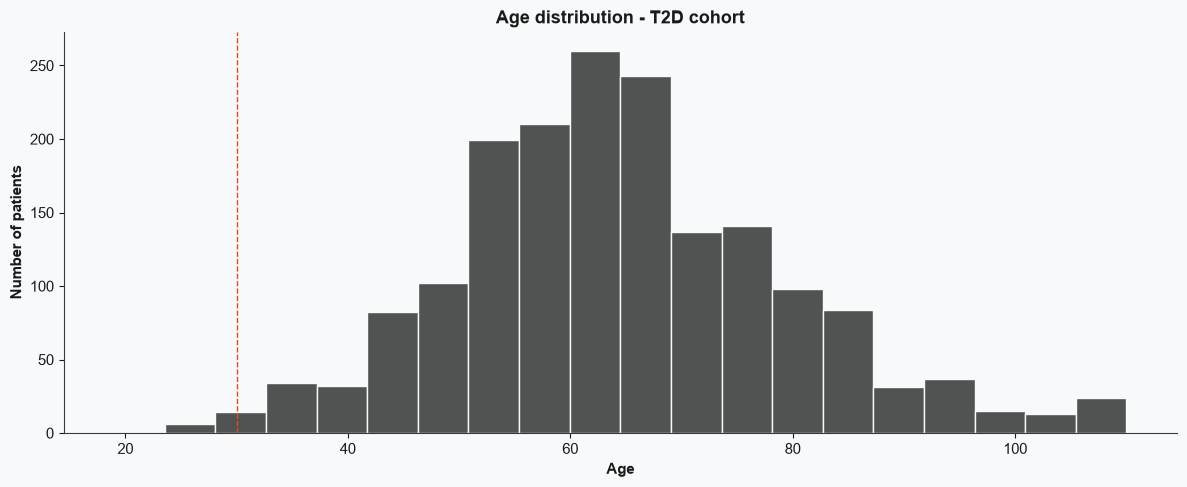

In [14]:
fig, ax = plt.subplots()
sns.histplot(cohort["AGE"], bins=20, color=COLOR_DARK, edgecolor=COLOR_BG, ax=ax)
ax.axvline(30, color=COLOR_ACCENT, linestyle="--", linewidth=1)
ax.set_xlabel("Age")
ax.set_ylabel("Number of patients")
ax.set_title("Age distribution - T2D cohort")
plt.tight_layout()
plt.show()

**Decision**: include all 1,763 patients in the main analysis, without special consideration for age. This is a result in itself that should be documented in the protocol: the planned exploratory step has been carried out, and it has led to the conclusion that, in this synthetic population, no relevant early-onset subgroup emerges (which is also plausible considering that Synthea generates realistic prevalences, and juvenile diabetes is indeed rare). We will add this to the protocol, along with the creatinine note, in a single update session.

In [15]:
# [Step 5]: merge lab features with demographic features into a single
# patient-level table

cohort_indexed = cohort.set_index("Id")

patient_features = patient_labs.join(cohort_indexed, how="inner")

print(patient_features.shape)
print(patient_features.isna().sum())

(1763, 15)
BMI                       0
Creatinine                0
Glucose                   0
HDL                       0
HbA1c                     0
LDL                       0
Total Cholesterol         0
Triglycerides             0
creatinine_measured       0
BIRTHDATE                 0
DEATHDATE              1345
RACE                      0
ETHNICITY                 0
GENDER                    0
AGE                       0
dtype: int64


In [16]:
# [Step 6a]: inspect which conditions are actually present in our cohort,
# to build a SNOMED -> Charlson category mapping grounded in real data
# (rather than guessing which codes might appear)

cohort_conditions = conditions[conditions["PATIENT"].isin(t2d_patients_set)]

condition_counts = (
    cohort_conditions
    .groupby(["CODE", "DESCRIPTION"])["PATIENT"]
    .nunique()
    .sort_values(ascending=False)
)

print(condition_counts.head(40))

CODE               DESCRIPTION                                                           
44054006           Diabetes mellitus type 2 (disorder)                                       1763
73595000           Stress (finding)                                                          1763
314529007          Medication review due (situation)                                         1763
160903007          Full-time employment (finding)                                            1760
237602007          Metabolic syndrome X (disorder)                                           1692
302870006          Hypertriglyceridemia (disorder)                                           1686
66383009           Gingivitis (disorder)                                                     1675
160904001          Part-time employment (finding)                                            1638
271737000          Anemia (disorder)                                                         1444
423315002          Limited s

In [17]:
# [Step 6b]: search for additional Charlson categories that might be present
# but with lower frequency than the top-40 view (e.g., cancer, stroke, COPD)

charlson_keywords = [
    "myocardial infarction", "heart failure", "peripheral vascular",
    "cerebrovascular", "stroke", "dementia", "pulmonary disease", "copd",
    "connective tissue", "rheumatoid", "lupus", "peptic ulcer",
    "liver disease", "hepatitis", "cirrhosis", "leukemia", "lymphoma",
    "metastatic", "malignant", "carcinoma", "tumor", "aids", "hiv",
    "hemiplegia", "paraplegia", "chronic kidney disease stage 3",
    "chronic kidney disease stage 4", "chronic kidney disease stage 5",
    "end-stage renal", "dialysis"
]

pattern = "|".join(charlson_keywords)

matches = (
    cohort_conditions[
        cohort_conditions["DESCRIPTION"].str.contains(pattern, case=False, na=False)
    ]
    .groupby(["CODE", "DESCRIPTION"])["PATIENT"]
    .nunique()
    .sort_values(ascending=False)
)

print(matches)

CODE            DESCRIPTION                                                          
433144002       Chronic kidney disease stage 3 (disorder)                                292
399211009       History of myocardial infarction (situation)                             282
431857002       Chronic kidney disease stage 4 (disorder)                                199
401314000       Acute non-ST segment elevation myocardial infarction (disorder)          151
401303003       Acute ST segment elevation myocardial infarction (disorder)              121
22298006        Myocardial infarction (disorder)                                         113
46177005        End-stage renal disease (disorder)                                       100
88805009        Chronic congestive heart failure (disorder)                               83
254837009       Malignant neoplasm of breast (disorder)                                   63
92691004        Carcinoma in situ of prostate (disorder)                     

**Mapping notes**: "Ischemic heart disease" (414545008) was excluded in favor of the
more specific myocardial infarction codes found in the data. "Carcinoma in situ of
prostate" (92691004) was excluded because in-situ (pre-invasive) neoplasms are not
counted by the standard Charlson Comorbidity Index, which targets invasive malignancy.
See `docs/protocol.md` for full methodology notes.

In [18]:
# [Step 6c]: compute the Charlson Comorbidity Index per patient
# Mapping grounded in conditions actually present in the cohort (Step 6a/6b)

CODE_TO_CATEGORY = {
    # Diabetes (mutually exclusive: complicated overrides uncomplicated)
    44054006: "diabetes",
    127013003: "diabetes_complicated",
    90781000119102: "diabetes_complicated",
    368581000119106: "diabetes_complicated",
    # Myocardial infarction
    399211009: "myocardial_infarction",
    401314000: "myocardial_infarction",
    401303003: "myocardial_infarction",
    22298006: "myocardial_infarction",
    # Congestive heart failure
    88805009: "chf",
    84114007: "chf",
    # Cerebrovascular disease
    230690007: "cerebrovascular_disease",
    # Renal disease (moderate/severe only; CKD stage 1/2 excluded by CCI definition)
    433144002: "renal_disease",
    431857002: "renal_disease",
    46177005: "renal_disease",
    # Malignancy (mutually exclusive: metastatic overrides non-metastatic)
    254837009: "malignancy",
    424132000: "malignancy",
    109838007: "malignancy",
    363406005: "malignancy",
    93761005: "malignancy",
    93143009: "malignancy",
    254632001: "malignancy",
    67811000119102: "malignancy",
    94503003: "metastatic_malignancy",
    94260004: "metastatic_malignancy",
    # Connective tissue disease
    69896004: "connective_tissue_disease",
    200936003: "connective_tissue_disease",
    # Mild liver disease
    128302006: "mild_liver_disease",
}

CHARLSON_WEIGHTS = {
    "diabetes": 1,
    "diabetes_complicated": 2,
    "myocardial_infarction": 1,
    "chf": 1,
    "cerebrovascular_disease": 1,
    "renal_disease": 2,
    "connective_tissue_disease": 1,
    "mild_liver_disease": 1,
    "malignancy": 2,
    "metastatic_malignancy": 6,
}

# mutually exclusive groups: keep only the highest-weight category present
EXCLUSIVE_GROUPS = [
    ("diabetes", "diabetes_complicated"),
    ("malignancy", "metastatic_malignancy"),
]

cohort_conditions = cohort_conditions.copy()
cohort_conditions["CHARLSON_CATEGORY"] = cohort_conditions["CODE"].map(CODE_TO_CATEGORY)

# one set of categories per patient (presence only; repeated diagnoses don't matter)
patient_categories = (
    cohort_conditions
    .dropna(subset=["CHARLSON_CATEGORY"])
    .groupby("PATIENT")["CHARLSON_CATEGORY"]
    .apply(set)
)


def compute_cci(categories: set) -> int:
    """Sum Charlson weights for a patient, keeping only the highest
    weight within each mutually exclusive group."""
    categories = set(categories)
    for low, high in EXCLUSIVE_GROUPS:
        if low in categories and high in categories:
            categories.discard(low)
    return sum(CHARLSON_WEIGHTS[c] for c in categories)


cci_scores = patient_categories.apply(compute_cci)

# patients with none of the mapped conditions -> CCI = 0, not missing
patient_features["CCI"] = patient_features.index.map(cci_scores).fillna(0).astype(int)

print(patient_features["CCI"].describe())
print(patient_features["CCI"].value_counts().sort_index())

count    1763.000000
mean        2.311968
std         1.445259
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        10.000000
Name: CCI, dtype: float64
CCI
1     630
2     566
3     191
4     235
5      87
6      31
7      14
8       3
9       2
10      4
Name: count, dtype: int64


In [19]:
# [Step 7a]: inspect which diabetes-relevant medications are present in the cohort

medications = pd.read_csv(
    data_dir / "medications.csv",
    usecols=["PATIENT", "CODE", "DESCRIPTION"]
)

cohort_medications = medications[medications["PATIENT"].isin(t2d_patients_set)]

medication_counts = (
    cohort_medications
    .groupby(["CODE", "DESCRIPTION"])["PATIENT"]
    .nunique()
    .sort_values(ascending=False)
)

print(medication_counts.head(30))

CODE     DESCRIPTION                                                                                                      
1535362  sodium fluoride 0.0272 MG/MG Oral Gel                                                                                1690
313521   tropicamide 5 MG/ML Ophthalmic Solution                                                                              1328
705129   Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray                                                                             918
860975   24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet                                                     890
866412   24 HR metoprolol succinate 100 MG Extended Release Oral Tablet                                                        881
313782   Acetaminophen 325 MG Oral Tablet                                                                                      798
312961   Simvastatin 20 MG Oral Tablet                                                     

In [20]:
# [Step 7b]: search for additional antidiabetic drug classes that might be
# present with lower frequency than the top-30 view

antidiabetic_keywords = [
    "metformin", "insulin",
    "glipizide", "glyburide", "glimepiride",          # sulfonylureas
    "empagliflozin", "canagliflozin", "dapagliflozin", # SGLT2 inhibitors
    "liraglutide", "semaglutide", "exenatide", "dulaglutide",  # GLP-1 agonists
    "sitagliptin", "linagliptin", "saxagliptin",       # DPP-4 inhibitors
    "pioglitazone", "rosiglitazone",                   # thiazolidinediones
]

pattern = "|".join(antidiabetic_keywords)

antidiabetic_matches = (
    cohort_medications[
        cohort_medications["DESCRIPTION"].str.contains(pattern, case=False, na=False)
    ]
    .groupby(["CODE", "DESCRIPTION"])["PATIENT"]
    .nunique()
    .sort_values(ascending=False)
)

print(antidiabetic_matches)

CODE     DESCRIPTION                                                                                          
860975   24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet                                        890
106892   insulin isophane  human 70 UNT/ML / insulin  regular  human 30 UNT/ML Injectable Suspension [Humulin]    534
311034   insulin  regular  human 100 UNT/ML Injectable Solution                                                   178
897122   3 ML liraglutide 6 MG/ML Pen Injector                                                                     17
865098   Insulin Lispro 100 UNT/ML Injectable Solution [Humalog]                                                    4
1373463  canagliflozin 100 MG Oral Tablet                                                                           4
Name: PATIENT, dtype: int64


**Feature engineering decision: grouping rare antidiabetic classes**

With only 4 out of 1,763 patients (0.2%) on SGLT2 inhibitors, a standalone column for
this class would be almost entirely zero, no clustering algorithm can form meaningful
groups based on a feature with near-zero variance. The same applies, to a lesser
extent, to GLP-1 agonists (17 patients, ~1%).

**Decision**: build separate binary columns only for the two well-represented classes
(metformin, insulin), and group GLP-1 agonists and SGLT2 inhibitors into a single
`on_other_antidiabetic` column. This preserves the signal "on a more recent/specialist
therapy" without introducing two near-constant features. See `docs/protocol.md` for the
full methodology note.

In [21]:
# [Step 7c]: build binary medication features
# Only metformin and insulin have enough patients to be informative as
# standalone features. GLP-1 (n=17) and SGLT2 (n=4) are grouped into a
# single "other_antidiabetic" feature - too rare individually to carry
# discriminative power for clustering.

METFORMIN_CODES = {860975}
INSULIN_CODES = {106892, 311034, 865098}
OTHER_ANTIDIABETIC_CODES = {897122, 1373463}  # liraglutide, canagliflozin

def patients_on(codes: set) -> set:
    return set(cohort_medications.loc[cohort_medications["CODE"].isin(codes), "PATIENT"])

on_metformin = patients_on(METFORMIN_CODES)
on_insulin = patients_on(INSULIN_CODES)
on_other = patients_on(OTHER_ANTIDIABETIC_CODES)

patient_features["on_metformin"] = patient_features.index.isin(on_metformin).astype(int)
patient_features["on_insulin"] = patient_features.index.isin(on_insulin).astype(int)
patient_features["on_other_antidiabetic"] = patient_features.index.isin(on_other).astype(int)

print(patient_features[["on_metformin", "on_insulin", "on_other_antidiabetic"]].sum())
print(f"\nOn no antidiabetic medication: "
      f"{((patient_features['on_metformin'] + patient_features['on_insulin'] + patient_features['on_other_antidiabetic']) == 0).sum()}")

on_metformin             890
on_insulin               658
on_other_antidiabetic     17
dtype: int64

On no antidiabetic medication: 516


**Interpretation of medication counts**

Metformin (890) and insulin (658) counts are as expected. `on_other_antidiabetic`
shows 17 rather than a possible maximum of 21 (17 + 4): the 4 patients on canagliflozin
are almost certainly a subset of those already on liraglutide (i.e., patients on
advanced combination therapy), not a counting error.

516 patients (29%) are on no antidiabetic medication at all, clinically plausible,
likely representing patients managed by diet/lifestyle alone, or with glycemic control
still borderline enough not to require pharmacological treatment. This is also relevant
for the clinical hypotheses defined in the protocol: it may overlap with the H2 cluster
("mild/late-onset").

In [22]:
# [Step 8]: healthcare utilization - number of encounters per year, for the cohort

encounters = pd.read_csv(
    data_dir / "encounters.csv",
    usecols=["PATIENT", "START"]
)

cohort_encounters = encounters[encounters["PATIENT"].isin(t2d_patients_set)].copy()
cohort_encounters["START"] = pd.to_datetime(cohort_encounters["START"])

# total encounters per patient
encounter_counts = cohort_encounters.groupby("PATIENT").size()

# observation period per patient: from first encounter to last available date
# (death date if deceased, otherwise the most recent encounter in the data)
first_encounter = cohort_encounters.groupby("PATIENT")["START"].min()
last_encounter = cohort_encounters.groupby("PATIENT")["START"].max()

observation_years = (last_encounter - first_encounter).dt.days / 365.25

# avoid division by zero for patients with a very short observation window
encounters_per_year = encounter_counts / observation_years.replace(0, 1)

patient_features["encounters_per_year"] = patient_features.index.map(encounters_per_year)

print(patient_features["encounters_per_year"].describe())

count    1763.000000
mean        2.422133
std         2.715935
min         0.430180
25%         0.935608
50%         1.310079
75%         2.484712
max        20.643369
Name: encounters_per_year, dtype: float64


**Interpretation of healthcare utilization**

The distribution is clinically plausible: a median of ~1.3 encounters/year, but with
strong right skew (max = 20.6, well beyond the 75th percentile of 2.5), a small
subgroup of patients with much heavier healthcare utilization than the majority. This
is clinically sensible: it likely overlaps with the patients already identified as
having elevated CCI or complications (renal, cardiovascular), who require more
frequent follow-up.

**Note for Phase 3**: this skew is also a useful technical flag. A variable this
imbalanced may require a transformation (e.g., log) before scaling, otherwise the few
extreme values risk dominating the Euclidean distance used by K-means.

In [23]:
# Export the final patient-level feature table for use in the upcoming
# Phase 3 (clustering) notebook, avoiding the need to re-run the full
# ETL pipeline (in particular, the chunked read of observations.csv).
# Parquet preserves exact dtypes on reload, unlike CSV.

from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

patient_features.to_parquet(processed_dir / "patient_features.parquet")

print(f"Saved: {patient_features.shape[0]} rows, {patient_features.shape[1]} columns")
print(patient_features.dtypes)

Saved: 1763 rows, 20 columns
BMI                             float64
Creatinine                      float64
Glucose                         float64
HDL                             float64
HbA1c                           float64
LDL                             float64
Total Cholesterol               float64
Triglycerides                   float64
creatinine_measured               int64
BIRTHDATE                datetime64[us]
DEATHDATE                datetime64[us]
RACE                                str
ETHNICITY                           str
GENDER                              str
AGE                               int64
CCI                               int64
on_metformin                      int64
on_insulin                        int64
on_other_antidiabetic             int64
encounters_per_year             float64
dtype: object
